# Plotagem de gráficos em Python
### Exemplo: solução analítica da viga de Euler-Bernoulli 
Definição das bibliotecas e parâmetros da viga

In [1]:
# Importar bibliotecas
import matplotlib.pyplot as plt
import numpy as np
# Definir valor dos parâmetros da viga
E,A,G,k,I,q0,L,h=200e9,50e-6,77e9,5/6,.15*.4**3/12,10,4,0.4

Início da Plotagem

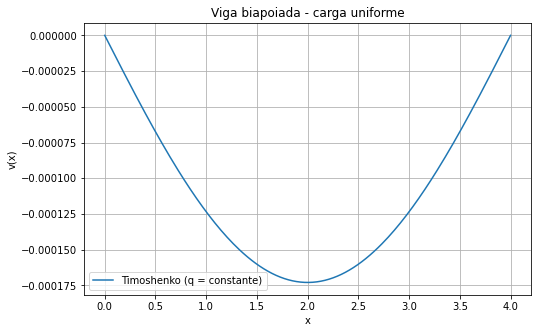

v(0) = -0.0
v(L) = 1.0842021724855044e-19


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros
E = 200e9
G = 77e9
A = 50e-6
I = 1e-6
k = 5/6
q0 = 10
L = 4

# domínio
x = np.linspace(0, L, 200)

# solução v(x) (carga constante)
v = (
        (A*G*k*x*((A*G*k*q0*L**3 + 12*q0*E*I*L)/(24*A**2*G**2*k**2)
        - (q0*x*(-A*G*k*x**2 + 6*E*I))/(6*A**2*G**2*k**2)))/(E*I)
        - (q0*x**4)/(4*E*I)
        - (A*G*k*x**3*((L*q0)/(2*A*G*k) - (q0*x)/(A*G*k)))/(6*E*I)
        + (q0*x**2*(-A*G*k*x**2 + 12*E*I))/(24*A*E*G*I*k)
)


# plot
plt.figure(figsize=(8,5))
plt.plot(x, v, label='Timoshenko (q = constante)')

plt.xlabel('x')
plt.ylabel('v(x)')
plt.title("Viga biapoiada - carga uniforme")
plt.grid(True)
plt.legend()
plt.show()

# checagem
print("v(0) =", v[0])
print("v(L) =", v[-1])

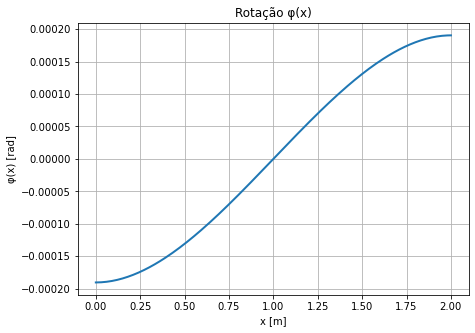

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros (ajuste para os seus valores reais)
L = 2.0
A = 0.01
E = 210e9
G = 80e9
I = 8.33e-6
k = 5/6
q0 = 1000

# domínio da viga
x = np.linspace(0, L, 200)

# função phi(x)
phi = (
    ((A*G*k*x**2)/(2*E*I) + 1)
    * ((L*q0)/(2*A*G*k) - (q0*x)/(A*G*k))
    
    + (q0*x**3)/(2*E*I)
    
    - (A*G*k*(
        (A*G*k*q0*L**3 + 12*q0*E*I*L)/(24*A**2*G**2*k**2)
        - (q0*x*(-A*G*k*x**2 + 6*E*I))/(6*A**2*G**2*k**2)
      ))/(E*I)
)

# plot
plt.figure(figsize=(7,5))
plt.plot(x, phi, linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('φ(x) [rad]')
plt.title('Rotação φ(x)')
plt.grid(True)
plt.show()

## Tensões 2D na viga biapoiada

🔹 Campos de tensão

- Tensão normal (flexão):
$$
\sigma_x(x,y) = E y \frac{d\phi}{dx}
$$


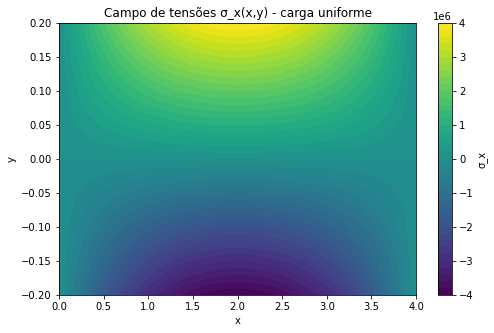

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros
E = 200e9
G = 77e9
A = 50e-6
I = 1e-6
k = 5/6
q0 = 10
L = 4
h = 0.4

# domínio
x = np.linspace(0, L, 100)
y = np.linspace(-h/2, h/2, 50)

X, Y = np.meshgrid(x, y)

# sigma_x(x,y) (carga constante)
# tensão sigma(x)
sigma = E*Y*(
      (3*q0*X**2)/(2*E*I)
    - (q0*((A*G*k*X**2)/(2*E*I) + 1))/(A*G*k)
    + (A*G*k*((q0*(-A*G*k*X**2 + 6*E*I))/(6*A**2*G**2*k**2)
    - (q0*X**2)/(3*A*G*k)))/(E*I)
    + (A*G*k*X*((L*q0)/(2*A*G*k) - (q0*X)/(A*G*k)))/(E*I)
)


# plot
plt.figure(figsize=(8,5))
cp = plt.contourf(X, Y, sigma, levels=50)
plt.colorbar(cp, label='σ_x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Campo de tensões σ_x(x,y) - carga uniforme')
plt.show()

## Tensões 2D na viga biapoiada

🔹 Campos de tensão
- Tensão de cisalhamento:
$$
\tau_{xy}(x) = k G \left(\phi - \frac{dv}{dx}\right)
$$

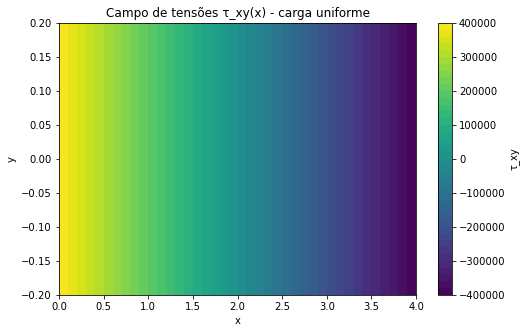

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros
E = 200e9
G = 77e9
A = 50e-6
I = 1e-6
k = 5/6
q0 = 10
L = 4
h = 0.4

# domínio
x = np.linspace(0, L, 100)
y = np.linspace(-h/2, h/2, 50)

X, Y = np.meshgrid(x, y)

# tau_xy(x) (carga constante)
tau = -G*k*(
      (5*q0*X**3)/(12*E*I)
    - ((A*G*k*X**2)/(2*E*I) + 1)* ((L*q0)/(2*A*G*k) - (q0*X)/(A*G*k))
    + (A*G*k*X**2*((L*q0)/(2*A*G*k) - (q0*X)/(A*G*k)))/(2*E*I)
    + (A*G*k*X*( (q0*(-A*G*k*X**2 + 6*E*I))/(6*A**2*G**2*k**2) - (q0*X**2)/(3*A*G*k)))/(E*I)
    - (q0*X*(-A*G*k*X**2 + 12*E*I)) /(12*A*E*G*I*k)
)

# plot
plt.figure(figsize=(8,5))
cp = plt.contourf(X, Y, tau, levels=50)
plt.colorbar(cp, label='τ_xy')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Campo de tensões τ_xy(x) - carga uniforme')
plt.show()